## Chapter 05 - Quantifying Confidence in our Decisions with *p*-values!

In this notebook we'll learn how to...
- Caclulate probabilities with the **Binomial Distribution**.
- Calculate *p*-values with the **Binomial Distribution**.
– Observe an increase in False Positives (Type 1-errors) when we use **One-Sided *p*-values**

In [1]:
# Importing necessary python packages
import numpy as np # to generate random numbers
import seaborn as sns # to draw graphs and have then look nice
from scipy.stats import binom, binomtest

### Calculate probabilities with the **Binomial Distribution**

We'll start by calculating probabilites for coin tosses with the `binom.pmf()` function. Here `pmf` stands for **Probability Mass Function** because discrete statistical distributions are also called **Mass Functions**.

`binom.pmf()` requires 3 parameters: `k` the number of successes, `n` the number of trials, and `p` the probability of getting a success. In our example, `k` is the amount of times we get heads, `n` the number of coin tosses, and `p` the probability of landing a head. 

In [5]:
# Calculated probability of landing two heads, in two coin tosses
print(binom.pmf(k=2, n=2, p=0.5)) 

0.25


In [7]:
# Calculated probability of landing 0 heads, in two tosses 
# (so landing 2 tails instead)
print(binom.pmf(0,2,0.5))

0.25


[0.25 0.5  0.25]


[Text(0.5, 0, 'Number of heads')]

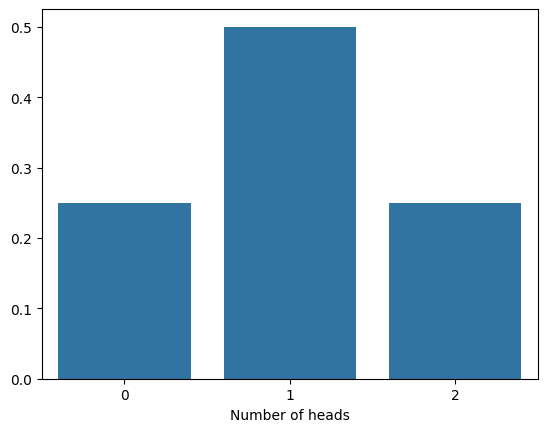

In [9]:
# If we want to produce a histogram graph to visualize the 
# probability distribution, for all combinations, we can 
# calculate all possibilities at once, with...

x_vals = [2, 1, 0]
prob_vals = binom.pmf(k=x_vals, n=2, p=0.5)
print(prob_vals)

# Inputing the data into the graphing function...
my_bar = sns.barplot(x=x_vals, y=prob_vals)
my_bar.set(xlabel='Number of heads')

Now that we know how to calculate probabilites with the **Binomial Distr.**, and draw a histogram plot with those probabilities, let's learn how to calculate *p*-values with the **Binomial Distribution**.

To calculate *p*-values with the **Binomial Distribution**, we can use the `binomtest()` function, set `k`, `n`, and `p`, and recieve our *p*-value output.

In [15]:
test_1 = binomtest(k=2, n=2, p=0.5)
print("p-value for 2 Heads in 2 coin tosses: ", test_1.pvalue)

test_2 = binomtest(4,5,0.5)
print("p-value of 4 Heads in 5 coin tosses: ", test_2.pvalue)

test_3 = binomtest(1, 10, 0.5)
print("p-value of 1 Heads in 10 coin tosses: ", test_3.pvalue)

p-value for 2 Heads in 2 coin tosses:  0.5
p-value of 4 Heads in 5 coin tosses:  0.375
p-value of 1 Heads in 10 coin tosses:  0.021484375


### Observe an increase in False Positives (Type-1 Errors) when using a **One-Sided *p*-value**

To observe how a one-sided *p*-value can increase the number of false positives, we're going to let the data bias our judgement. We'll use `rbinom()` to generate random numbers based on a **Binomial Distr.** with 1000 trials – using a normal coin.

If the number of Heads is greater than (>) 500, we'll test the hypothesis that our coin is normal, with a one-sided *p*-value that onlu uses the side of the histogram that's representing Heads (ignoring the side representing Tails).

If the number of Tails is greater than (>) 500, we'll do the opposite. As such, we're letting the data bias us into our choice of direction for the one-sided hypothesis, and associated one-sided *p*-value.

If more than 5% of these tests are false positives, we've managed to capture and observe an increase in False Positives; an increase which we want to avoid. We'll also calculate the two-sided *p*-values for each number of Heads we get, so that we can compare the results.

In [18]:
# Since we're going to generate random datasets,
# we want to begin by setting the seed so that the results are
# reproduceable.

np.random.seed(42)

num_rand_datasets = 10000 ## The experiment is reproduced ten thousand times

# Create empty arrays that are num_rand_datasets in length.
# We want to reproduce the experiment as many times for both cases,
# in order to make the comparison as fair as possible
one_sided_p_values = np.empty(num_rand_datasets)
two_sided_p_values = np.empty(num_rand_datasets)

num_coin_flips = 1000 # The experiment involves flipping a thousand coins

# Here is the loop where we create a bunch of random datasets,
# and then calculate a one-sided p-value for them, selecting
# the side that is more favorable to what we observed.

for i in range(num_rand_datasets):
    # First, figure out how many heads we got in num_coin_flips tosses
    # The binomial (0.5) ensures the coin we are testing on is fair and normal
    num_heads = np.random.binomial(n=num_coin_flips, p=0.5)

    # Now, calculate a two-sided p-value for that experiment, so
    # that we can save it for the comparison later on.
    two_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5).pvalue

    # Now, calculate a biased one-sided p-value
    # that looks at the number of heads and decides
    # which side to calculate the p-value with.
    if num_heads > (num_coin_flips / 2):
        one_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5, alternative='greater').pvalue
    else:
        one_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5, alternative='less').pvalue

# First, let's see how many false positives we get with the two-sided p-values
two_sided_num_false = np.sum(two_sided_p_values < 0.05)
print("% of false positives from the two-sided hypothesis and associated p-values: ", two_sided_num_false / num_rand_datasets)

% of false positives from the two-sided hypothesis and associated p-values:  0.0483


With a threshold of 0.05, we expect about 5% of decisions to fail into false positives, and we got just a little bit less than that. Now let's calculate the same for the data-biased one-sided hypotheses and associated p-values.  

In [21]:
# First, determine the number of false positives for the one-sided p-values
num_false_positives = np.sum(one_sided_p_values < 0.05)
print("% of false positives from the ONE-sided hypothesis and associated p-values: ", num_false_positives / num_rand_datasets)

% of false positives from the ONE-sided hypothesis and associated p-values:  0.0978


As we can see, almost 10% of the *p*-values of the one-sided hypotheses and p-values, turned out as false positives. So, there it is – an example as to why **One-Sided *p*-values** can be tricky, and should be avoided – unless we really have to use them, and simultaneously understand how to conduct our calculations without being biased by the data (going in blind instead).